---
title: ✅ Week 02 Lab - Student Solutions
subtitle: 2024/25 Winter Term
author: The DS202 Team
date: 27 January 2025
jupyter: python3
---

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📋 Lab Tasks

## 🛠 Part 1: Data manipulation with `pandas` (45 min)

### ✨ **`pandas` data frame attributes**

A `pandas` data frame has a lot of attributes, several of which we shall explore:

-   `shape`: shows the number of rows and columns.
-   `index`: prints the name of each row in the data frame.
-   `columns`: prints the name of each column in the data frame.

### 🔧 **`pandas` data frame methods**

`pandas` data frames have a lot of methods! We will focus our attention on the following:

-   `head` / `tail`: shows the first / last *n* observations of a data frame.
-   `to_frame`: converts a series (`pandas` will automatically convert a data frame into a series if one variable is selected) to a data frame.
-   `unique`: shows all unique values for qualitative features selected.
-   `value_counts`: counts the number of times a unique value appears in a qualitative feature.
-   `query`: keeps rows that conform to one or more logical criteria.
-   `reset_index`: a subset of a data frame will keep the index of an old data frame. We use this method to change the index to one integer increments.
-   `filter`: keeps columns that are included in a user-supplied list (via the `items` parameter).
-   `drop`: drops columns that are included in a user-supplied list.
-   `rename`: renames already existing columns based on a user-supplied dictionary.
-   `assign`: creates a new variable based on a `lambda` function.
-   `apply`: applies a `lambda` function across a set of variables.
-   `get_dummies`: transforms qualitative features into a series of dummy features.
-   `groupby`: perform grouped calculations within qualitative features.

**Import `gapminder`**

In [6]:
gapminder = pd.read_csv("../data/gapminder.csv")

### 1.1: Printing `pandas` data frames

Let's print `gapminder`.

In [7]:
# Printing the object itself
print(gapminder)

# Printing the first 5 rows
print(gapminder.head(5))

# Printing the last 5 rows
print(gapminder.tail(5))

          country continent  year  lifeExp       pop   gdpPercap
0     Afghanistan      Asia  1952   28.801   8425333  779.445314
1     Afghanistan      Asia  1957   30.332   9240934  820.853030
2     Afghanistan      Asia  1962   31.997  10267083  853.100710
3     Afghanistan      Asia  1967   34.020  11537966  836.197138
4     Afghanistan      Asia  1972   36.088  13079460  739.981106
...           ...       ...   ...      ...       ...         ...
1699     Zimbabwe    Africa  1987   62.351   9216418  706.157306
1700     Zimbabwe    Africa  1992   60.377  10704340  693.420786
1701     Zimbabwe    Africa  1997   46.809  11404948  792.449960
1702     Zimbabwe    Africa  2002   39.989  11926563  672.038623
1703     Zimbabwe    Africa  2007   43.487  12311143  469.709298

[1704 rows x 6 columns]
       country continent  year  lifeExp       pop   gdpPercap
0  Afghanistan      Asia  1952   28.801   8425333  779.445314
1  Afghanistan      Asia  1957   30.332   9240934  820.853030
2  Afghan

We can see the dimensions of our data by calling the shape attribute of `gapminder`.

In [8]:
gapminder.shape

(1704, 6)

Here, we find that `gapminder` has 1,704 rows and 6 columns.

### 1.2: Data frames and series

We can see that `gapminder` has a list of countries and continents. We will explore continents further. To select only the continent column, we quote the variable name inside brackets next to `gapminder`.

In [9]:
gapminder["continent"]

0         Asia
1         Asia
2         Asia
3         Asia
4         Asia
         ...  
1699    Africa
1700    Africa
1701    Africa
1702    Africa
1703    Africa
Name: continent, Length: 1704, dtype: object

You can also reference variables using `.`:

In [10]:
gapminder.continent

0         Asia
1         Asia
2         Asia
3         Asia
4         Asia
         ...  
1699    Africa
1700    Africa
1701    Africa
1702    Africa
1703    Africa
Name: continent, Length: 1704, dtype: object

👉 **NOTE:** If you have variables separated by any white space or variables that contain special characters such as `-` or `@`, you can only use the brackets notation to select a column. The . (dot) notation can only be used for column names that are valid Python identifiers (e.g., no spaces, must start with a letter or underscore, and contain only alphanumeric characters or underscores).

This changes the data frame to a series. If you want the output to remain a data frame, however, you can use the `to_frame` method.

In [11]:
gapminder["continent"].to_frame()

,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Asia
...,...
1699,Africa
1700,Africa
1701,Africa
1702,Africa


### 1.3: Finding / counting unique values

To find the names of all the continents we can use the `unique` method.

In [12]:
gapminder["continent"].unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

To see how many times each continent appears, we can use the `value_counts` method. We use reset index in order to turn `continent` into its own column.

In [14]:
gapminder["continent"].value_counts().reset_index()

,continent,count
0,Africa,624
1,Asia,396
2,Europe,360
3,Americas,300
4,Oceania,24


In [16]:
gapminder["year"].value_counts().reset_index()

,year,count
0,1952,142
1,1957,142
2,1962,142
3,1967,142
4,1972,142
5,1977,142
6,1982,142
7,1987,142
8,1992,142
9,1997,142


❓**Question:** Do you see anything odd?

### 1.4: Performing grouped calculations

Suppose we want to calculate average GDP per capita across time. We can use a combination of the `groupby` and `mean` methods from `Pandas`.

In [17]:
gapminder.groupby("year", as_index=False)["gdpPercap"].mean()

,year,gdpPercap
0,1952,3725.276046
1,1957,4299.408345
2,1962,4725.812342
3,1967,5483.653047
4,1972,6770.082815
5,1977,7313.166421
6,1982,7518.901673
7,1987,7900.920218
8,1992,8158.608521
9,1997,9090.175363


### 1.5: Subsetting rows

Suppose we want to investigate as to why Oceania has only 24 observations (see **Part 1.3**), we can start by using the `query` method, which filters rows by one or more conditions.

In [18]:
gapminder_oceania = gapminder.query("continent == 'Oceania'")

📝**Task:** Find the unique values of country in `gapminder_oceania`.

In [20]:
# Code here
gapminder_oceania["country"].unique()

array(['Australia', 'New Zealand'], dtype=object)

In [22]:
gapminder[gapminder['continent'] == "Oceania"]['country'].unique()

array(['Australia', 'New Zealand'], dtype=object)

❓**Question:** Do you see the reason now?

### 1.6: Subsetting columns

Suppose we only want our data frame to include country, year and population. We can use the `filter` method in a Pandas data frame setting the `items` parameter equal to a list of feature names that we want to include.

In [23]:
gapminder.filter(items=["country","year","pop"])

,country,year,pop
0,Afghanistan,1952,8425333
1,Afghanistan,1957,9240934
2,Afghanistan,1962,10267083
3,Afghanistan,1967,11537966
4,Afghanistan,1972,13079460
...,...,...,...
1699,Zimbabwe,1987,9216418
1700,Zimbabwe,1992,10704340
1701,Zimbabwe,1997,11404948
1702,Zimbabwe,2002,11926563


Another option is to use the `drop` method which takes a list of features to drop. Here, we specify `axis=1` which signifies columns, not rows (to specify rows, we set `axis=0`).

In [ ]:
gapminder.drop(["lifeExp","continent","gdpPercap"],axis=1)

Yet another way to achieve the same result as the `filter` and `drop` methods we've just shown is the double square bracket subsetting:

In [24]:
gapminder[["country","year","pop"]]

,country,year,pop
0,Afghanistan,1952,8425333
1,Afghanistan,1957,9240934
2,Afghanistan,1962,10267083
3,Afghanistan,1967,11537966
4,Afghanistan,1972,13079460
...,...,...,...
1699,Zimbabwe,1987,9216418
1700,Zimbabwe,1992,10704340
1701,Zimbabwe,1997,11404948
1702,Zimbabwe,2002,11926563


👉 **NOTE:** If you have used `pandas`, you may have used the `loc` and `iloc` methods on data frames. These functions enable users to select both columns and rows in one function. While, in theory, this sounds great, these methods are computationally inefficient, so we advise that you do not use these methods and, instead, opt for `query` and `filter`.

### 1.7: Renaming columns

It is good practice to convert variable names to "snake case" whereby all characters are lower case and each word in the variable is separated by an underscore. To find the variable names expressed as an index, we call the `columns` attribute.

In [25]:
gapminder.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='object')

From there, we can amend the variable names using a dictionary where the *key* is the current variable name and the *value* is the variable name you would like it to be. We then use the `rename` method, setting the `columns` parameter equal to the dictionary created.

In [26]:
# Create a dictionary of variable names using snake case
snake_case_var_names = {
    "country": "country",
    "continent": "continent",
    "year": "year",
    "lifeExp": "life_exp",
    "pop": "pop",
    "gdpPercap": "gdp_per_cap",
}

# Set the columns attribute to this list
gapminder = gapminder.rename(columns=snake_case_var_names)

# Check the columns attribute
gapminder.columns

Index(['country', 'continent', 'year', 'life_exp', 'pop', 'gdp_per_cap'], dtype='object')

### 1.8: Creating new variables

We know that Gross Domestic Product can be obtained from multiplying GDP per capita and population. To do this in Pandas, we simply insert `*` between the `gdp_per_cap` and `pop` columns found in `gapminder`.

In [27]:
gapminder["gdp"] = gapminder["gdp_per_cap"] * gapminder["pop"]
gapminder

,country,continent,year,life_exp,pop,gdp_per_cap,gdp
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,6.567086e+09
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,7.585449e+09
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,8.758856e+09
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,9.648014e+09
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,9.678553e+09
...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,6.508241e+09
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,7.422612e+09
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,9.037851e+09
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,8.015111e+09


After having calculated GDP, you may be interested in coding whether or not a country has above median GDP. We can turn `where` in Numpy into a function and create a new column using the `assign` method.

In [28]:
# Returns a booleian array if a quantitative feature is above median values
def is_above_median(var):
  return np.where(var > np.median(var), True, False)

# Apply the function to GDP
gapminder[["country","year","gdp"]].assign(above_median = lambda x: is_above_median(x["gdp"]))

,country,year,gdp,above_median
0,Afghanistan,1952,6.567086e+09,False
1,Afghanistan,1957,7.585449e+09,False
2,Afghanistan,1962,8.758856e+09,False
3,Afghanistan,1967,9.648014e+09,False
4,Afghanistan,1972,9.678553e+09,False
...,...,...,...,...
1699,Zimbabwe,1987,6.508241e+09,False
1700,Zimbabwe,1992,7.422612e+09,False
1701,Zimbabwe,1997,9.037851e+09,False
1702,Zimbabwe,2002,8.015111e+09,False


👉 **NOTE:** When using `assign` you can see that we use `lambda x:` followed by the function. All we are doing is using `x` as a placeholder for our data frame (`country`, `year` and `gdp`). In doing so, we can select the column we are interested in using to create our new boolean variable.

💁**Tip:** You may have noticed that we can string multiple methods together in Pandas. This is extremely useful, but you might find that your code will get too "long". If you find this to be the case, you can use `\` to spread your code over multiple lines. Here's an example of how to do this with the above code:

In [29]:
gapminder[["country","year","gdp"]].\
    assign(above_median = lambda x: is_above_median(x["gdp"]))

,country,year,gdp,above_median
0,Afghanistan,1952,6.567086e+09,False
1,Afghanistan,1957,7.585449e+09,False
2,Afghanistan,1962,8.758856e+09,False
3,Afghanistan,1967,9.648014e+09,False
4,Afghanistan,1972,9.678553e+09,False
...,...,...,...,...
1699,Zimbabwe,1987,6.508241e+09,False
1700,Zimbabwe,1992,7.422612e+09,False
1701,Zimbabwe,1997,9.037851e+09,False
1702,Zimbabwe,2002,8.015111e+09,False


📝**Task:** This output is not very helpful. Try using some of the commands we have gone over to create a more useful data frame.

In [32]:
# Code here
gapminder[['country','year','gdp']].\
    assign(above_median = lambda x: is_above_median(x['gdp'])).\
           query('above_median == True').\
              drop(columns='above_median', axis=1).\
                reset_index(drop=True)


,country,year,gdp
0,Afghanistan,2007,3.107929e+10
1,Algeria,1952,2.272563e+10
2,Algeria,1957,3.095611e+10
3,Algeria,1962,2.806140e+10
4,Algeria,1967,4.143324e+10
...,...,...,...
847,Vietnam,2007,2.081746e+11
848,"Yemen, Rep.",1992,2.512511e+10
849,"Yemen, Rep.",1997,3.351236e+10
850,"Yemen, Rep.",2002,4.179396e+10


### 1.9: Preparing data for `scikit-learn`, an example

📝**Task:** Filter the data to only include observations from 2007.

In [35]:
# Code here
gapminder_2007 = gapminder.query("year == 2007")
gapminder_2007

,country,continent,year,life_exp,pop,gdp_per_cap,gdp
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,3.107929e+10
23,Albania,Europe,2007,76.423,3600523,5937.029526,2.137641e+10
35,Algeria,Africa,2007,72.301,33333216,6223.367465,2.074449e+11
47,Angola,Africa,2007,42.731,12420476,4797.231267,5.958390e+10
59,Argentina,Americas,2007,75.320,40301927,12779.379640,5.150336e+11
...,...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404,2.081746e+11
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,1.215686e+10
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,5.065987e+10
1691,Zambia,Africa,2007,42.384,11746035,1271.211593,1.493170e+10


📝**Task:** Create a list of numeric variables (life expectancy, population, GDP per capita, and GDP) and string variables (continent).

In [ ]:
# Code here

📝**Task:** Subset the new data frame to only include these variables. **Remember** you can add elements to a list by using `+`.

In [ ]:
# Code here

We will now apply `standardise` to numeric variables

In [ ]:
# Create a function that standardises variables
def standardise(var):
    return (var - var.mean()) / var.std()


# Apply standardise function over all numeric variables
gapminder_07_normal = gapminder_07.filter(items=num_vars).apply(
    lambda x: standardise(x), axis=0
)

❓ Can you find a function in `scikit-learn` that will help you standardise numeric data without having to write your own function?

👉 **NOTE:** Normalising continuous features is good practice in machine learning, and becomes essential when dealing with algorithms that employ some kind of distance measure, such as principle components analysis.

Along with normalising features, we need to transform categorical features into one-hot encoded dummy (that is, 0 or 1) features. One-hot simply means that a reference category in a feature will not appear in the transformed data frame. To apply one-hot encoding, we can use `get_dummies` in `Pandas`.

In [ ]:
gapminder_07_dummies = pd.get_dummies(
    gapminder_07["continent"], columns=["continent"], drop_first=True, dtype=int
)
print(gapminder_07_dummies)

After having transformed our continuous and categorical features, we can concatenate the two into a new data frame.

In [ ]:
gapminder_07_cleaned = pd.concat([gapminder_07_normal, gapminder_07_dummies], axis=1)
gapminder_07_cleaned

👉 **NOTE:** These kinds of transformations and concatenations will be employed **a lot** during this course, so please be sure to get used to them.

As a final (optional) step, we can convert our Pandas data frame to a Numpy array by employing the `to_numpy` method.

In [ ]:
gapminder_07_cleaned.to_numpy()

🏆**Challenge:** Which countries had above average life expectancy in 1952?

Try these steps: 

1. Define a function that returns a boolean if a value in a feature exceeds the average value. 
2. Include only the year 1952 by using `query`. 
3. Subset the data frame to only include country and life expectancy using `filter`. 
4. Create a new boolean variable using the user defined function using `assign`. 
5. Include all rows with above average life expectancy using `query`. 
6. Subset the data frame to only include country using square bracket indexing. 
7. Pull the unique values into an array using `unique`.

In [ ]:
# Code here

❓ Suggest another way of solving the challenge that doesn't follow the steps above.

In [ ]:
# Code here

## 📋 Part 2: Data visualisation with `lets_plot`(45 min)

They say a picture paints a thousand words, and we are, more often than not, inclined to agree with them (whoever "they" are)! Thankfully, we can use a number of different graphical libraries. Some of the more popular graphical libraries in Python include:

-   [`matplotlib`:](https://matplotlib.org/) Python's premier plotting library.

-   [`seaborn`:](https://seaborn.pydata.org/) A package that builds upon `matplotlib` to produce high-quality visualisations with greater ease.

-   [`plotly`:](https://plotly.com/python/) Plotly allows you to create publication quality interactive visualisations.

-   [`lets_plot`](https://lets-plot.org/): Python's version of `ggplot2`. An added bonus is that you can get interactivity in the graphs. `lets_plot` is less well-known in the Python community but if you have done so much as dabble in R, you will be well-aware of the syntax.

## 2. Visualisation Design Principles

When creating effective data visualisations, the focus should be on design principles that enhance clarity, accessibility, and insight generation rather than just technical implementation. This section explores key visualisation types through a design-first lens.

### 2.1 Histograms: Revealing Distributions

Histograms excel at showing the shape and spread of continuous data. For the **life_exp** distribution in the gapminder dataset, consider these principles:

In [39]:
num_vars = ["life_exp", "pop", "gdp_per_cap", "gdp"]

In [50]:
import lets_plot
LetsPlot.setup_html()

In [58]:
(
    ggplot(gapminder, aes('life_exp'))+
    geom_histogram(bins=40, alpha=0.75) +
    theme(panel_grid_major=element_blank())
)

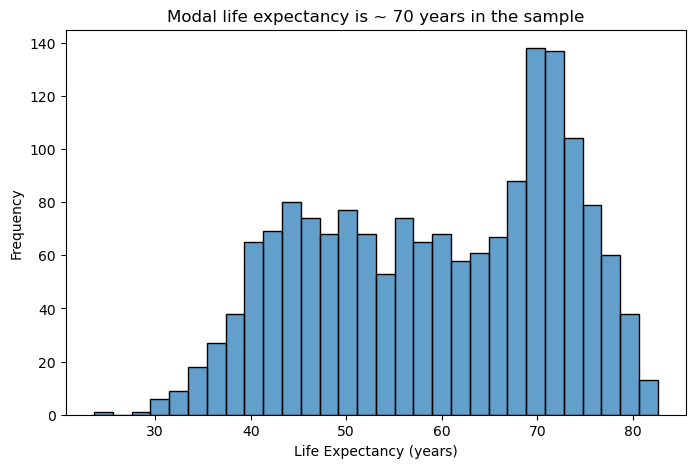

In [40]:
# Basic histogram for life expectancy
plt.figure(figsize=(8, 5))
sns.histplot(data=gapminder, x="life_exp", bins=30, alpha=0.7)
plt.title("Modal life expectancy is ~ 70 years in the sample")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Frequency")
plt.show()

**Design Considerations:**
- **Bin width matters**: Too few bins oversimplify the distribution; too many create noise. Start with 20-40 bins for most datasets and adjust based on your data's characteristics.
- **Transparency aids comparison**: Using alpha transparency (0.5-0.8) allows overlapping distributions to remain visible when comparing groups.
- **Reduce visual clutter**: Remove unnecessary grid lines, especially vertical ones that compete with the bars for attention.
- **Clear labeling**: Descriptive axis labels help readers understand what they're viewing without referring to external documentation.

**👥 DESIGN EXERCISE:**
Consider how adjusting bin count affects the story your histogram tells. Experiment with transparency levels to find the balance between visibility and clarity. Think about when vertical grid lines add value versus when they create visual noise.

In [ ]:
# Code here

### 2.2 Bar Charts: Comparing Categories

Bar charts are the workhorse of categorical data visualisation. When visualising the number of countries by **continent** in the gapminder dataset, their strength lies in making comparisons easy and immediate.

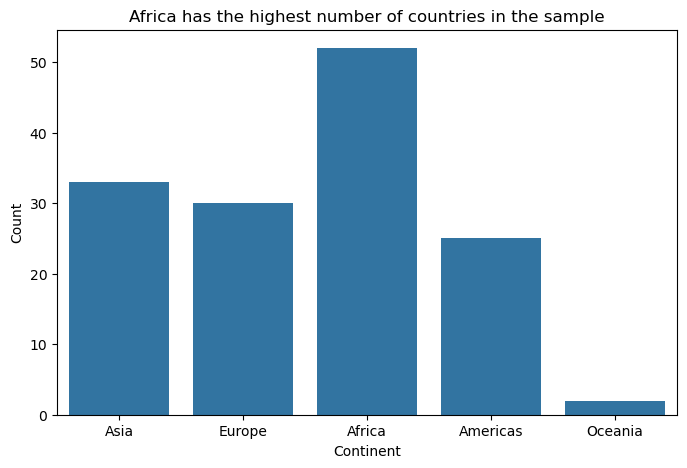

In [41]:
# Filter data for 1997 (similar to original example)
gapminder_97 = gapminder[gapminder['year'] == 1977]  # Using 1977 as we have it in sample data

# Basic bar chart for continent counts
plt.figure(figsize=(8, 5))
sns.countplot(data=gapminder_97, x="continent")
plt.title("Africa has the highest number of countries in the sample")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.show()

**Design Principles:**
- **Start from zero**: Bar length represents magnitude, so truncated axes can mislead viewers about relative differences.
- **Order thoughtfully**: Arrange categories by frequency, alphabetically, or by meaningful progression rather than randomly.
- **Minimise decoration**: Remove unnecessary elements like 3D effects, heavy borders, or excessive grid lines that don't aid comprehension.
- **Consider orientation**: Horizontal bars work better for long category names and make labels more readable.

**👥 DESIGN EXERCISE:**
Practice creating clean, focused bar charts. Consider when to use horizontal versus vertical orientation. Experiment with different ordering strategies and observe how they change the story your visualisation tells.

In [ ]:
# Code here

In [ ]:
gapminder_contcount = gapminder.value_counts("continent").reset_index()



In [67]:
(
ggplot(gapminder_contcount, aes(x='continent', y='count')) +
    geom_bar(stat='identity') +
    theme(panel_grid_major_x=element_blank())
)

### 2.3 Scatter Plots: Exploring Relationships

Scatter plots reveal relationships between continuous variables and are essential for exploratory data analysis. When examining the relationship between **gdp_per_cap** and **life_exp** in the gapminder data, they help visualise potential correlations and patterns.

In [ ]:
# Basic scatter plot for GDP per capita vs life expectancy
plt.figure(figsize=(8, 6))
sns.scatterplot(data=gapminder, x="gdp_per_cap", y="life_exp", alpha=0.6)
plt.title("Past average incomes of $10,000, life expectancy improvement slows down")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy (years)")
plt.show()

**Effective Design Strategies:**
- **Handle overplotting**: Use transparency, jittering, or smaller point sizes when dealing with many overlapping points.
- **Scale appropriately**: Consider log transformations for skewed data to reveal relationships that might be hidden in linear scales.
- **Guide the eye**: Clear axis labels and appropriate scales help viewers understand the relationship being shown.
- **Show uncertainty**: Consider adding trend lines or confidence intervals when appropriate to highlight patterns.

**👥 DESIGN EXERCISE:**
Explore how different transformations (log, square root) can reveal hidden patterns in your data. Practice using transparency effectively to handle overplotting while maintaining readability.

In [ ]:
# Code here

### 2.4 Line Charts: Tracking Change Over Time

Line charts excel at showing trends, patterns, and changes over time or other continuous sequences. For tracking average **gdp_per_cap** across **year** in the gapminder dataset, they reveal long-term economic trends.

In [ ]:
# Calculate average GDP per capita by year
gdp_per_cap_by_year = gapminder.groupby("year")["gdp_per_cap"].mean().reset_index()

# Basic line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=gdp_per_cap_by_year, x="year", y="gdp_per_cap")
plt.title(
    "The average country has seen per capita incomes rise from 4,000 to 12,000 USD"
)
plt.xlabel("Year")
plt.ylabel("Average GDP per Capita")
plt.show()

**Design Best Practices:**
- **Connect meaningfully**: Only connect points where the progression between them is meaningful (typically time-based data).
- **Choose appropriate styling**: Dotted lines can suggest uncertainty or projection; solid lines imply measured data.
- **Layer thoughtfully**: Combining points with lines helps readers identify individual measurements while seeing the overall trend.
- **Scale to show variation**: Ensure your y-axis scale reveals meaningful variation without exaggerating minor fluctuations.
- **Consider filled areas**: Area charts can effectively show cumulative quantities or emphasize the magnitude of change, but use them judiciously.

**👥 DESIGN EXERCISE:**
Experiment with different line styles to convey different types of information. Consider when adding area fill enhances understanding versus when it creates confusion. Practice setting appropriate time axis intervals that match your data's natural rhythm.

In [ ]:
# Code here

### 2.5 Box Plots: Summarizing Distributions Across Groups

Box plots efficiently communicate multiple statistical measures while enabling group comparisons. When comparing **pop** distributions across **continent** in the gapminder dataset, they reveal differences in medians, spreads, and outliers between geographic regions.

In [ ]:
# Filter data for 1982 and exclude Oceania (similar to original example)
gapminder_oceania_82 = gapminder[
    (gapminder["continent"] != "Oceania") & (gapminder["year"] == 1982)
]

# Basic box plot with log scale
plt.figure(figsize=(8, 6))
sns.boxplot(data=gapminder_oceania_82, x="continent", y="pop")
plt.yscale("log")
plt.title("Distribution of Population by Continent (1982, excluding Oceania)")
plt.xlabel("Continent")
plt.ylabel("Population (log scale)")
plt.xticks(rotation=45)
plt.show()

**Design Considerations:**
- **Handle extreme values**: Log scales can be essential when comparing groups with very different ranges or when dealing with skewed data.
- **Simplify visual elements**: Remove unnecessary grid lines that don't aid in reading values or making comparisons.
- **Provide context**: Clear group labels and axis titles help viewers understand what comparisons they're making.
- **Consider alternatives**: Violin plots or strip charts might better serve your purpose when sample sizes are small or when showing full distributions is important.

**👥 DESIGN EXERCISE:**
Practice deciding when log transforms reveal meaningful patterns. Experiment with removing different grid elements to create cleaner, more focused visualisations.

In [ ]:
# Code here

### 2.6 Density Plots: Understanding Continuous Distributions

Density plots provide smooth representations of data distributions and are particularly useful for comparing multiple groups. When examining the distribution of **gdp** values in a specific year from the gapminder dataset, they reveal the shape and concentration of economic development across countries.

In [ ]:
# Filter data for 1952 (similar to original example)
gapminder_52 = gapminder[gapminder["year"] == 1952]

# Basic density plot (only density curve, no histogram)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=gapminder_52, x="gdp")
plt.xscale("log")
plt.title("Density Distribution of GDP (1952)")
plt.xlabel("GDP (log scale)")
plt.ylabel("Density")
plt.show()

**Effective Design Elements:**
- **Transform when needed**: Log scales can reveal patterns in skewed data that would be invisible on linear scales.
- **Minimise visual noise**: Reduce grid lines and other decorative elements that don't contribute to understanding.
- **Consider bandwidth**: The smoothing parameter affects how much detail versus generalisation your plot shows.
- **Enable comparison**: When showing multiple densities, use transparency and distinct colors to enable easy comparison.

**👥 DESIGN EXERCISE:**
Explore how different transformations affect the insights you can draw from density plots. Practice balancing detail with clarity by adjusting smoothing parameters.

In [ ]:
# Code here

### Universal Design Principles

Across all visualisation types, several principles enhance effectiveness:

**Accessibility:** Ensure your visualisations work for colorblind viewers and can be understood in black and white. Use patterns, shapes, and positioning alongside color.

**Clarity:** Every element should serve a purpose. Remove or de-emphasize anything that doesn't directly contribute to understanding your data.

**Context:** Provide enough information for viewers to understand what they're seeing without overwhelming them with unnecessary detail.

**Consistency:** Use consistent scales, colors, and styling across related visualisations to enable easy comparison.

**Focus:** Direct attention to the most important insights through strategic use of color, size, and positioning.

Remember: the goal of data visualisation is to facilitate understanding and insight, not to showcase technical capabilities. Always prioritize clarity and accessibility over visual complexity.